# Dimensionless (self-normalized) plots

Takes the JSON files of the **most current run**, builds the self-normalized
data, and draws the dimensionless figures.

Each quantity is rescaled by its first (initial, pre-evaporation) element,
$X_i / X_0$, and plotted against $T_i / T_0$, so every curve starts at $1$.

Two views are produced:
- the original **overview** (6-panel scatter) and standalone $C_P-C_V$;
- four **split line-figures** (for all traps & statistics): per-particle
  energies, compressibility/expansion, heat capacities, and $N$ vs $T$.

Every plot function accepts `xscale` / `yscale` (any matplotlib scale) so you
can choose the axis scaling per figure.

## 0. Imports & configuration

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

try:
    import evap_cool  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd()))
    import evap_cool  # noqa: F401

from evap_cool import (
    list_sessions, list_runs,
    normalize_session, load_normalized, build_normalized_traps,
    plot_dimensionless_overview, plot_cp_minus_cv,
    plot_energies_per_particle, plot_compressibility,
    plot_heat_capacities, plot_n_vs_t,
)

# --- Configuration ---------------------------------------------------------
RUNS_DIR = Path("runs")
FIG_DIR  = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# --- Axis scaling ----------------------------------------------------------
# Choose the scale for every figure. Any matplotlib scale name works:
#   "linear", "log", "symlog", "asinh", "logit", ...
# Leave as None to keep each figure's sensible default (all log-log; the
# overview keeps kappa_T/B_P on log-y and the rest linear with robust limits).
XSCALE = 'log'
YSCALE = 'log'

## 1. Locate the most current run

In [4]:
sessions = list_sessions(RUNS_DIR)
if not sessions:
    raise SystemExit(f"No sessions under {RUNS_DIR.resolve()}; set RUNS_DIR.")

session = sessions[-7]
print(f"Most current session: {session}")

source_runs = [p for p in list_runs(session, include_thermo=False)
               if not p.stem.endswith("_norm")]
print(f"\nSource run files ({len(source_runs)}):")
for p in source_runs:
    thermo = p.with_name(p.stem + "_thermo.json")
    print(f"  {p.name}{'  + thermo' if thermo.exists() else '  (no thermo)'}")

Most current session: runs\2026-06-06\00h38m10s

Source run files (15):
  box2d_osc1d_bosons.json  + thermo
  box2d_osc1d_fermions.json  + thermo
  box2d_osc1d_mb.json  + thermo
  box_bosons.json  + thermo
  box_fermions.json  + thermo
  box_mb.json  + thermo
  osc2d_box1d_bosons.json  + thermo
  osc2d_box1d_fermions.json  + thermo
  osc2d_box1d_mb.json  + thermo
  oscillator_bosons.json  + thermo
  oscillator_fermions.json  + thermo
  oscillator_mb.json  + thermo
  quadrupole_bosons.json  + thermo
  quadrupole_fermions.json  + thermo
  quadrupole_mb.json  + thermo


## 2. Generate the normalized data

Merges each run with its thermo sibling, rescales every quantity by its first
element, **and precomputes the per-particle $X/N$** quantities (schema v2).

In [5]:
norm_files = normalize_session(session, verbose=True)
print(f"\nWrote {len(norm_files)} normalized files")

  normalized -> box2d_osc1d_bosons_norm.json
  normalized -> box2d_osc1d_fermions_norm.json
  normalized -> box2d_osc1d_mb_norm.json
  normalized -> box_bosons_norm.json
  normalized -> box_fermions_norm.json
  normalized -> box_mb_norm.json
  normalized -> osc2d_box1d_bosons_norm.json
  normalized -> osc2d_box1d_fermions_norm.json
  normalized -> osc2d_box1d_mb_norm.json
  normalized -> oscillator_bosons_norm.json
  normalized -> oscillator_fermions_norm.json
  normalized -> oscillator_mb_norm.json
  normalized -> quadrupole_bosons_norm.json
  normalized -> quadrupole_fermions_norm.json
  normalized -> quadrupole_mb_norm.json

Wrote 15 normalized files


## 3. Sanity check

In [6]:
res = load_normalized(sorted(norm_files)[0])["results"]
print("available series:", ", ".join(k for k in res if res[k] is not None))
print("\nfirst value (should be 1.0 where defined):")
for k in ("T","N","Omega","kappa_T","B_P",
          "Omega_over_N","CV_over_N","CP_minus_CV_over_N"):
    v = res.get(k)
    if v:
        print(f"  {k:>20}: {v[0]}")

available series: N, T, Mu, E, Omega, S, P, H, F, G, CV, CP, kappa_T, B_P, alpha, CP_minus_CV, Omega_over_N, F_over_N, G_over_N, CV_over_N, CP_over_N, CP_minus_CV_over_N

first value (should be 1.0 where defined):
                     T: 1.0
                     N: 1.0
                 Omega: 1.0
               kappa_T: 1.0
                   B_P: 1.0
          Omega_over_N: 1.0
             CV_over_N: 1.0
    CP_minus_CV_over_N: 1.0


## 4. Build the trap structure

In [7]:
traps = build_normalized_traps(session)
for t in traps:
    stats = [s for s in ("mb","bosons","fermions") if s in t]
    print(f"  {t['name']:<14} (key={t['key']}): {', '.join(stats)}")

  Box2d_osc1d    (key=box2d_osc1d): mb, bosons, fermions
  Box            (key=box): mb, bosons, fermions
  Osc2d_box1d    (key=osc2d_box1d): mb, bosons, fermions
  Oscillator     (key=oscillator): mb, bosons, fermions
  Quadrupole     (key=quadrupole): mb, bosons, fermions


## 5. Split figures (for all traps & statistics)

Trap &rarr; colourblind-safe Okabe-Ito colour; statistic &rarr; line style
(MB solid, BE dashed, FD dotted) with a lighter shade for BE and darker for
FD. A statistic key sits in every subplot; the trap key is below each figure.
Axis scaling comes from `XSCALE` / `YSCALE` above.

### 5.1 Energies per particle &mdash; $|\Omega/N|$, $|F/N|$, $|G/N|$

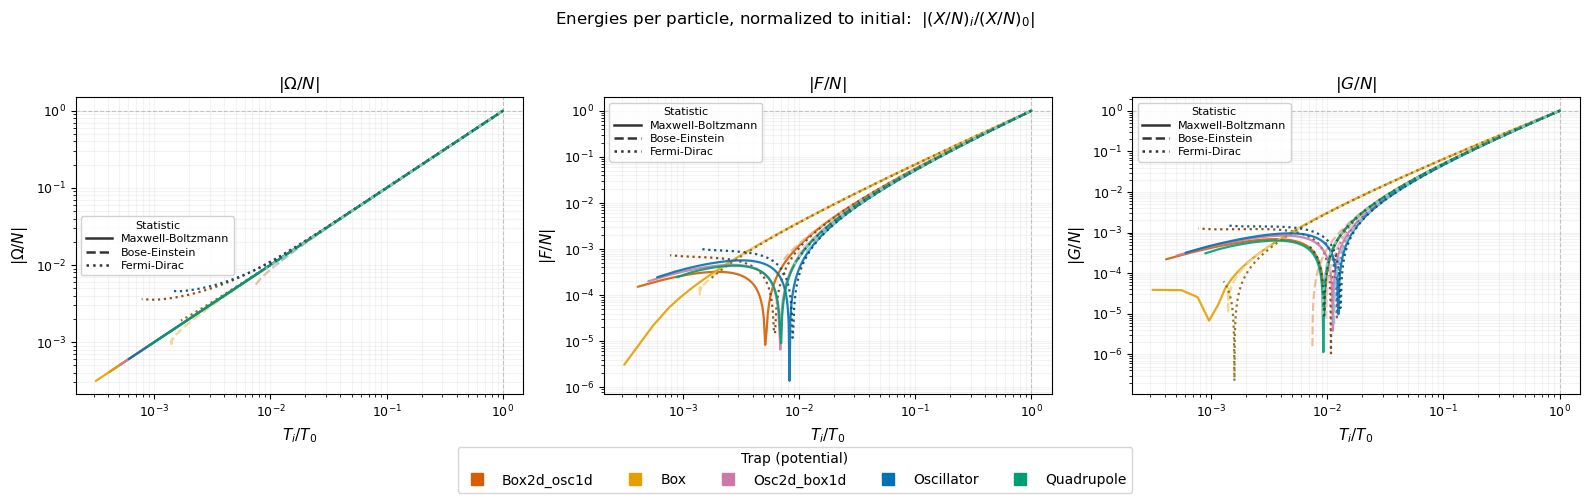

In [10]:
fig1 = plot_energies_per_particle(traps, xscale=XSCALE, yscale=YSCALE)
fig1.savefig(FIG_DIR / "fig1_energies_per_particle.png", dpi=500, bbox_inches="tight")
plt.show()

### 5.2 Compressibility & expansion &mdash; $\kappa_T$, $B_P$
With the dash-dot BE/FD separatrix (toggle `divide_be_fd=False`).

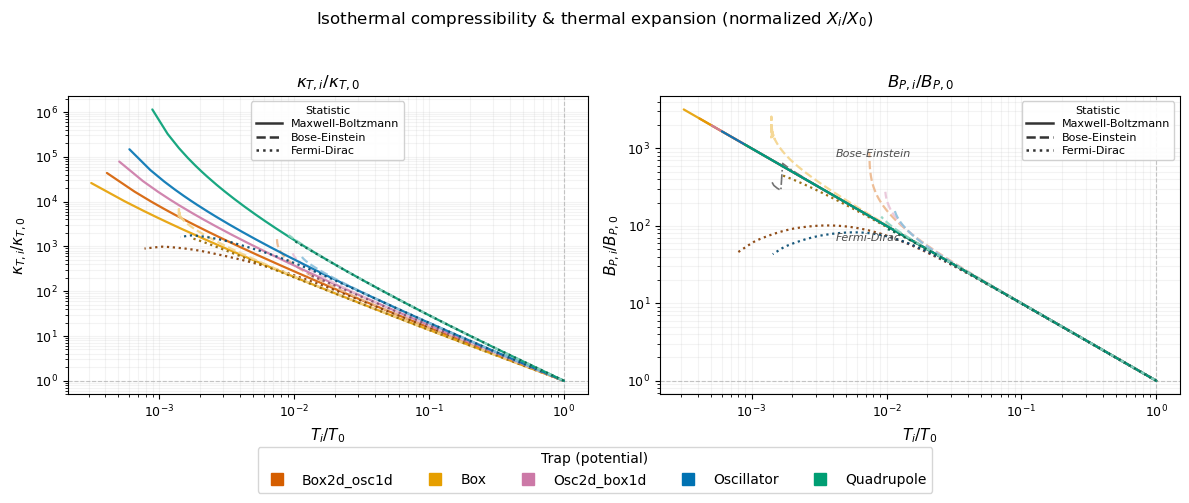

In [14]:
fig2 = plot_compressibility(traps, xscale=XSCALE, yscale=YSCALE, divide_be_fd=True)
fig2.savefig(FIG_DIR / "fig2_compressibility.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.3 Heat capacities per particle &mdash; $|C_V/N|$, $|C_P/N|$, $|(C_P-C_V)/N|$

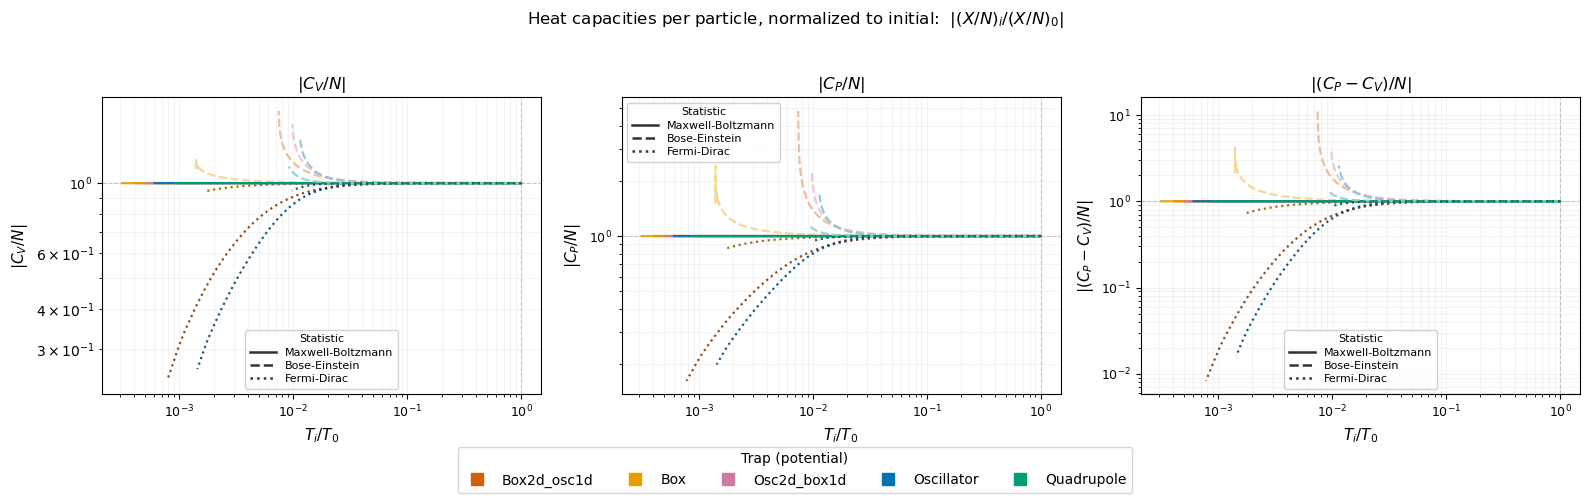

In [18]:
# Tip: for a semilog-x view of this figure, pass yscale="linear".
fig3 = plot_heat_capacities(traps, xscale=XSCALE, yscale=YSCALE)
fig3.savefig(FIG_DIR / "fig3_heat_capacities.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.4 Population &mdash; $N_i/N_0$ vs $T_i/T_0$

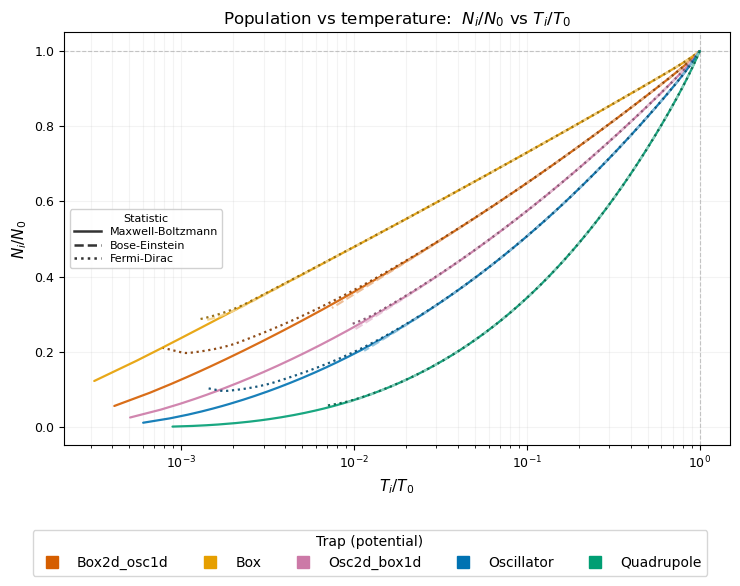

In [22]:
fig4 = plot_n_vs_t(traps, xscale=XSCALE, yscale="linear")
fig4.savefig(FIG_DIR / "fig4_N_vs_T.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Original views (kept for reference)

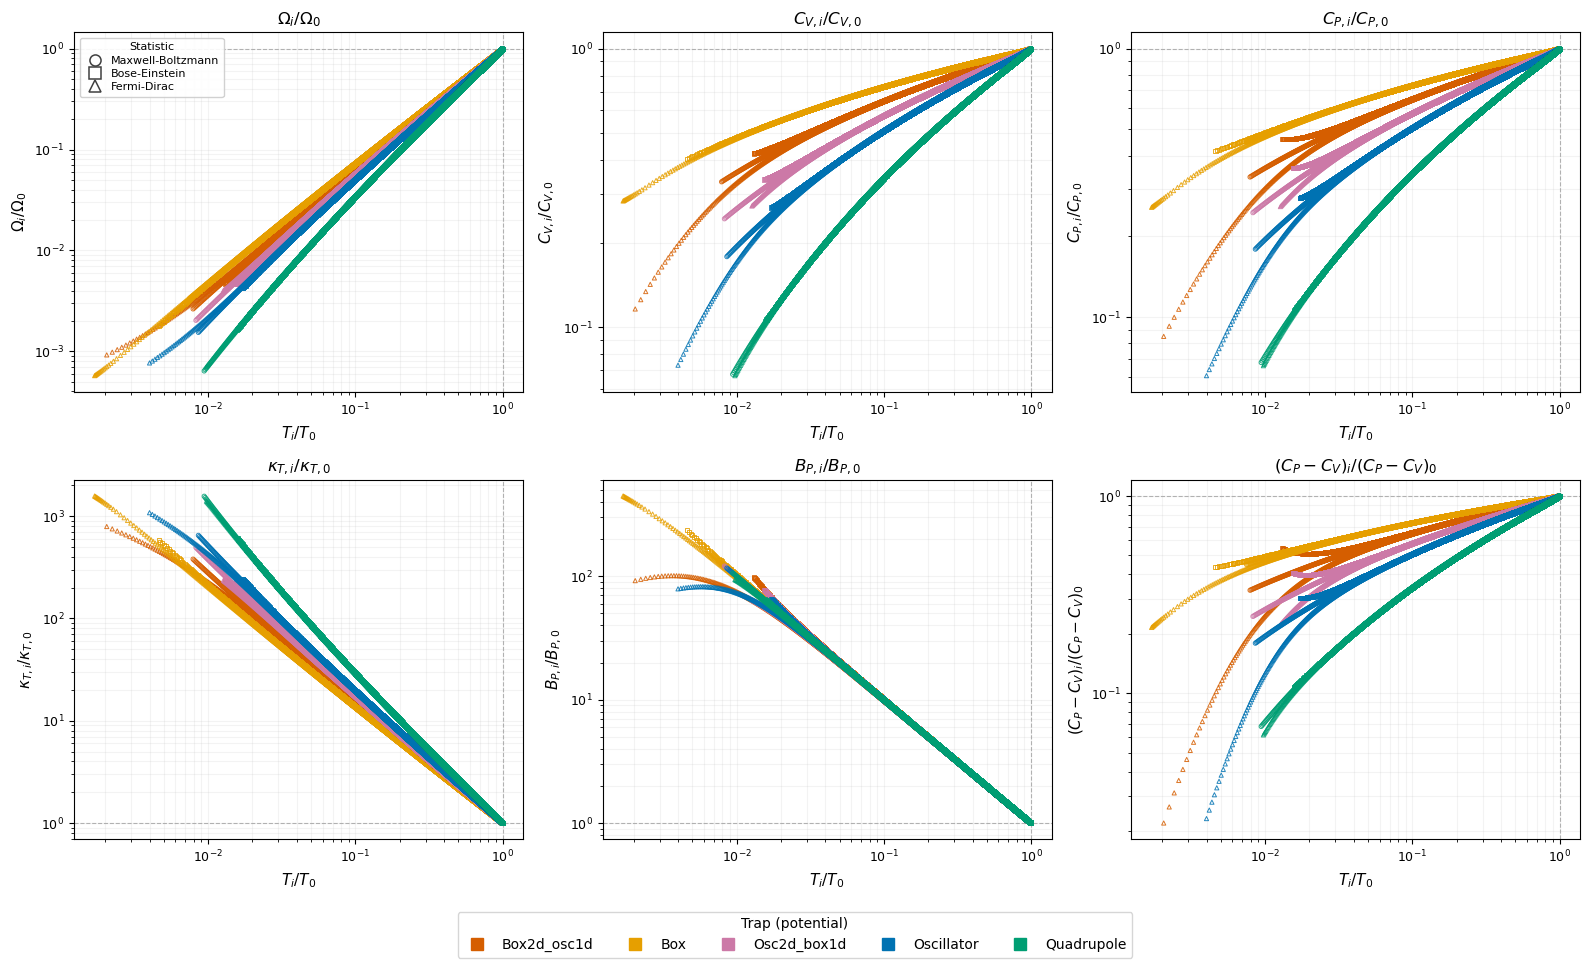

In [21]:
# yscale=None keeps the per-panel default (kappa_T/B_P log-y, others linear);
# pass e.g. yscale="log" to force every panel onto the same scale.
fig = plot_dimensionless_overview(
    traps, xscale=XSCALE, yscale=YSCALE,
    robust_ylim=True, ylim_pct=YLIM_PCT, trim_tail=TRIM_TAIL, stride=STRIDE,
)
fig.savefig(FIG_DIR / "dimensionless_overview.png", dpi=300, bbox_inches="tight")
plt.show()

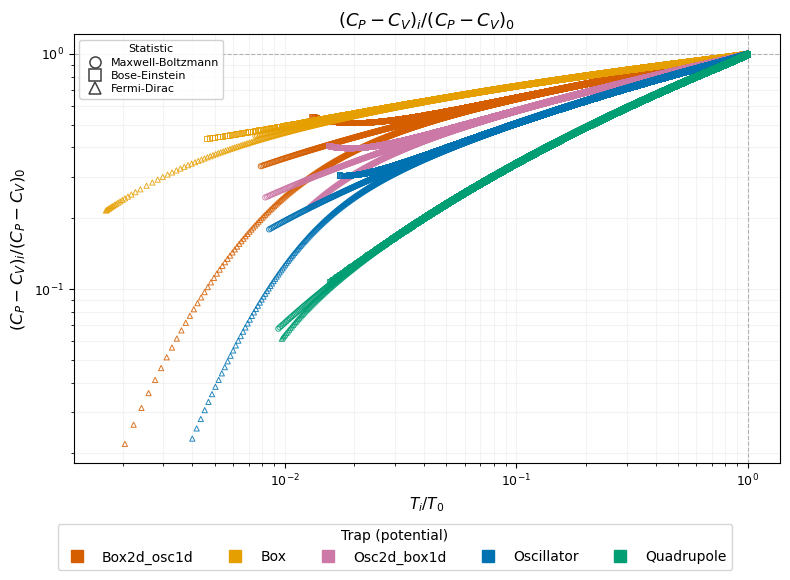

In [22]:
fig_cpcv = plot_cp_minus_cv(traps, xscale=XSCALE, yscale=YSCALE,
                            ylim_pct=YLIM_PCT, trim_tail=TRIM_TAIL, stride=STRIDE)
fig_cpcv.savefig(FIG_DIR / "cp_minus_cv.png", dpi=300, bbox_inches="tight")
plt.show()

## Notes & knobs

- **Axis scales** &mdash; every plot function takes `xscale` / `yscale`
  (any matplotlib scale: "linear", "log", "symlog", "asinh", "logit", ...).
  They override the older `log_x` / `log_y` booleans. On the overview,
  `yscale` (when set) forces *all* panels to that scale; left as None it
  keeps the per-panel default. Override per call, e.g.
  `plot_heat_capacities(traps, yscale="linear")`.
- **Per-particle quantities** &mdash; $X/N$ = normalized $X$ over normalized
  $N$, i.e. $(X/N)_i/(X/N)_0$ (dimensionless, starts at 1). Precomputed into
  the v2 `*_norm.json` files.
- **Magnitudes** &mdash; the per-particle and compressibility figures plot
  $|X|$ (the energies and $G/N=\mu$ are negative).
- **BE/FD divider** &mdash; Figure 2 draws a geometric-mean separatrix only
  where the bundles separate; `divide_be_fd=False` hides it.
- **Colours** &mdash; `evap_cool.TRAP_COLORS` (Okabe-Ito); shade offsets are
  `STAT_LIGHTEN` / `STAT_DARKEN` in `plots_dimensionless`.
- **Re-running** &mdash; execute again after new runs + post-processing;
  `normalize_session` overwrites the `*_norm.json` files (v2).